# Idiomatic Bias in Hate Speech Detection with Figurative Language
**Research** — Multilingual hate speech detection (EN/ES/PT)  
**Hypothesis**: Language models systematically fail to detect figurative hate speech outside of English, demonstrating idiomatic bias.  

---
### Notebook Structure
1. **Installation and setup**
2. **Dataset loading (EN/ES/PT)**
3. **Section A — Fine-tuned models** (XLM-R, mBERT)
4. **Section B — LLMs via prompting** (LLaMA-3.1-8B via Groq)
5. **Comparative analysis and visualization**

> **Before starting**: `Runtime → T4 GPU`

---
## 1. Installation and Setup

In [ ]:
!pip install transformers torch scikit-learn groq pandas matplotlib seaborn tqdm --quiet
print('Dependencies installed')

Dependencies installed


In [ ]:
import os
import json
import time
import requests
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    classification_report, f1_score,
    precision_score, recall_score, confusion_matrix
)

COLORS = {
    'en': '#2980B9', 'es': '#E67E22', 'pt': '#27AE60',
    'hate': '#C0392B', 'no_hate': '#2980B9',
    'xlmr': '#8E44AD', 'mbert': '#16A085',
    'llama': '#E74C3C', 'baseline': '#95A5A6'
}

SEED = 42
np.random.seed(SEED)
print('Libraries loaded')

Libraries loaded


In [ ]:
# Configuring the Groq API key
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
    print('API key loaded from Colab Secrets')
except Exception:
    GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '')
    if GROQ_API_KEY:
        print('API key loaded from environment variable')
    else:
        print('API key not found. Set GROQ_API_KEY before Section B.')

API key loaded from Colab Secrets


---
## 2. Dataset Loading (EN / ES / PT)

| Language | Dataset | Source | Size |
|----------|---------|--------|------|
| English | Davidson et al. (2017) | Twitter | 24,783 tweets |
| Spanish | HaterNet — Pereira-Kohatsu et al. (2019) | Twitter | 6,000 tweets |
| Portuguese | HateBR — Vargas et al. (2022) | Instagram | 7,000 comments |

> All datasets are native — **no machine translation was used**. This ensures that model failures reflect genuine idiomatic bias, not translation artifacts.

In [ ]:
# ── ENGLISH: Davidson et al. (2017) ────────────────────────────────────────
URL_EN = (
    "https://huggingface.co/datasets/tdavidson/hate_speech_offensive"
    "/resolve/main/data/train-00000-of-00001.parquet"
)
df_en = pd.read_parquet(URL_EN, engine="pyarrow")
df_en = df_en.rename(columns={"tweet": "text", "class": "HS"})
df_en["HS"] = df_en["HS"].apply(lambda x: 1 if x == 0 else 0)
df_en["lang"] = "en"
df_en = df_en[["text", "HS", "lang"]]
print(f"EN: {len(df_en):,} tweets | Hate: {df_en['HS'].sum():,} ({df_en['HS'].mean()*100:.1f}%)")

# ── SPANISH: HaterNet — Pereira-Kohatsu et al. (2019, Zenodo CC-BY 4.0) ────
URL_ES = "https://zenodo.org/records/2592149/files/labeled_corpus_6K.txt?download=1"
r = requests.get(URL_ES)
r.raise_for_status()
registros = []
for linea in r.text.splitlines():
    partes = linea.split(";||;")
    if len(partes) == 3:
        _, texto, etiqueta = partes
        try:
            registros.append({"text": texto.strip(), "HS": int(etiqueta.strip()), "lang": "es"})
        except ValueError:
            pass
df_es = pd.DataFrame(registros)
print(f"ES: {len(df_es):,} tweets | Hate: {df_es['HS'].sum():,} ({df_es['HS'].mean()*100:.1f}%)")

# ── PORTUGUESE: HateBR — Vargas et al. (2022, GitHub CC-BY 4.0) ─────────────
URL_PT = "https://raw.githubusercontent.com/franciellevargas/HateBR/main/dataset/HateBR.csv"
df_pt = pd.read_csv(URL_PT)
df_pt = df_pt.rename(columns={'comentario': 'text', 'label_final': 'HS'})
df_pt['HS'] = df_pt['HS'].apply(lambda x: 0 if x == 0 else 1)
df_pt['lang'] = 'pt'
df_pt = df_pt[['text', 'HS', 'lang']].dropna()
print(f"PT: {len(df_pt):,} comments | Hate: {df_pt['HS'].sum():,} ({df_pt['HS'].mean()*100:.1f}%)")

EN: 24,783 tweets | Hate: 1,430 (5.8%)
ES: 6,000 tweets | Hate: 1,567 (26.1%)
PT: 7,000 comments | Hate: 3,500 (50.0%)


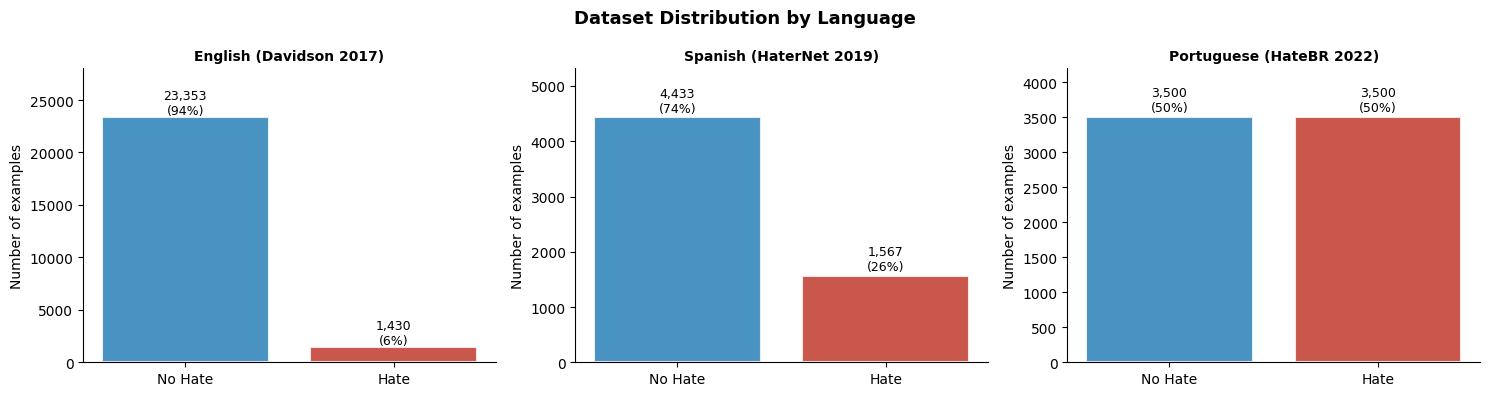

In [ ]:
# ── Dataset distribution visualization ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dataset Distribution by Language', fontsize=13, fontweight='bold')

for ax, (df, lang, color) in zip(axes, [
    (df_en, 'English (Davidson 2017)', COLORS['en']),
    (df_es, 'Spanish (HaterNet 2019)', COLORS['es']),
    (df_pt, 'Portuguese (HateBR 2022)', COLORS['pt'])
]):
    counts = df['HS'].value_counts().sort_index()
    bars = ax.bar(['No Hate', 'Hate'], counts.values,
                  color=[COLORS['no_hate'], COLORS['hate']], alpha=0.85,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(lang, fontweight='bold', fontsize=10)
    ax.set_ylabel('Number of examples')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}\n({val/len(df)*100:.0f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, max(counts.values) * 1.2)

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Sample examples from each language and class ───────────────────────────
def show_examples(df, lang_name, n=4):
    print(f"\n{'='*65}")
    print(f" {lang_name.upper()} — EXAMPLE PHRASES")
    print(f"{'='*65}")
    print(f"\n  HATE SPEECH examples:")
    hate_samples = df[df['HS'] == 1].sample(n, random_state=SEED)
    for i, (_, row) in enumerate(hate_samples.iterrows(), 1):
        text = row['text'][:120] + '...' if len(row['text']) > 120 else row['text']
        print(f"    [{i}] {text}")
    print(f"\n  NO HATE examples:")
    nohate_samples = df[df['HS'] == 0].sample(n, random_state=SEED)
    for i, (_, row) in enumerate(nohate_samples.iterrows(), 1):
        text = row['text'][:120] + '...' if len(row['text']) > 120 else row['text']
        print(f"    [{i}] {text}")

show_examples(df_en, 'English (Davidson 2017)')
show_examples(df_es, 'Spanish (HaterNet 2019)')
show_examples(df_pt, 'Portuguese (HateBR 2022)')


 ENGLISH (DAVIDSON 2017) — EXAMPLE PHRASES

  HATE SPEECH examples:
    [1] @AustinG1135 I do not like talking to you faggot and I did but in a nicely way fag
    [2] RT @mitchmancuso: @BrantPrintup:What straight guys take a picture of themselves naked in a hot tun.What fags @jakesiwy @...
    [3] @clinchmtn316 @sixonesixband AMERICA today, the rule of thumb is: when in doubt, blame "whitey"
    [4] @STACCS_WNT_FOLD you tell me, coon.

  NO HATE examples:
    [1] @kiela_g_3 Home fag. Didn't feel like puttin up with your shit today
    [2] GTA online today bitch ass niggas
    [3] Can u say hoe hoe hoe? Ewww she was nasty. I was so mean to her on the daily. I'll spare the details lol.
    [4] @itzbreak that spear chucker? Hell no.

 SPANISH (HATERNET 2019) — EXAMPLE PHRASES

  HATE SPEECH examples:
    [1] @_Futbolero_ metete en la cueva con los otros maricon
    [2] @ChBlures @ZdeZombi tolai parguelas comecojones subnormal payaso bocaalcornoque tontopollas pajizo gilipollas cabezabuqu

In [ ]:
# ── Balanced stratified sample for the experiment ──────────────────────────
N_PER_CLASS = 250

def balanced_sample(df, n=N_PER_CLASS, seed=SEED):
    hate    = df[df['HS'] == 1].sample(min(n, df['HS'].sum()), random_state=seed)
    no_hate = df[df['HS'] == 0].sample(min(n, (df['HS']==0).sum()), random_state=seed)
    return pd.concat([hate, no_hate], ignore_index=True).sample(frac=1, random_state=seed)

sample_en = balanced_sample(df_en)
sample_es = balanced_sample(df_es)
sample_pt = balanced_sample(df_pt)

print(f"   Balanced samples for the experiment:")
print(f"   EN: {len(sample_en)} | Hate: {sample_en['HS'].sum()} | No-hate: {(sample_en['HS']==0).sum()}")
print(f"   ES: {len(sample_es)} | Hate: {sample_es['HS'].sum()} | No-hate: {(sample_es['HS']==0).sum()}")
print(f"   PT: {len(sample_pt)} | Hate: {sample_pt['HS'].sum()} | No-hate: {(sample_pt['HS']==0).sum()}")
samples = {'en': sample_en, 'es': sample_es, 'pt': sample_pt}

   Balanced samples for the experiment:
   EN: 500 | Hate: 250 | No-hate: 250
   ES: 500 | Hate: 250 | No-hate: 250
   PT: 500 | Hate: 250 | No-hate: 250


---
## Section A — Fine-tuned Models (XLM-R, mBERT)

This part evaluate pre-trained hate speech detection models — no additional training required, just load and predict.

| Model | Training language | Architecture |
|-------|------------------|--------------|
| `Hate-speech-CNERG/dehatebert-mono-english` | English only | mBERT |
| `cardiffnlp/twitter-roberta-base-hate-latest` | English only | RoBERTa |
| `IMSyPP/hate_speech_en` | Multilingual | XLM-R |

> **Key question**: If a model was trained primarily on English data, how much does its performance drop on Spanish and Portuguese? This drop measures idiomatic bias.

In [ ]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print(f"{'GPU available: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else '⚠️  Using CPU (slower)'}")

GPU available: Tesla T4


In [ ]:
def evaluate_hf_model(model_name, samples_dict, label_mapping=None, batch_size=32, max_length=128):
    """
    Evaluates a HuggingFace model across 3 languages.
    Returns a dict with metrics per language.
    """
    print(f"\n Loading {model_name}...")
    try:
        clf = pipeline(
            "text-classification",
            model=model_name,
            tokenizer=model_name,
            device=device,
            truncation=True,
            max_length=max_length
        )
    except Exception as e:
        print(f" Error loading model: {e}")
        return None

    results = {}
    for lang, df in samples_dict.items():
        texts      = df['text'].tolist()
        true_labels = df['HS'].tolist()
        raw_preds  = []

        for i in tqdm(range(0, len(texts), batch_size),
                      desc=f"  [{lang.upper()}]", leave=False):
            batch = texts[i:i+batch_size]
            try:
                preds = clf(batch, truncation=True)
                raw_preds.extend(preds)
            except Exception:
                raw_preds.extend([{'label': 'LABEL_0', 'score': 0.5}] * len(batch))

        pred_labels = []
        for p in raw_preds:
            label = p['label'].upper()
            if label_mapping:
                pred_labels.append(label_mapping.get(label, 0))
            else:
                pred_labels.append(
                    1 if any(k in label for k in ['1', 'HATE', 'OFFENSIVE', 'TOXIC', 'HOF']) else 0
                )

        f1_macro = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
        f1_hate  = f1_score(true_labels, pred_labels, pos_label=1, zero_division=0)
        prec     = precision_score(true_labels, pred_labels, pos_label=1, zero_division=0)
        rec      = recall_score(true_labels, pred_labels, pos_label=1, zero_division=0)

        results[lang] = {
            'f1_macro':  round(f1_macro, 4),
            'f1_hate':   round(f1_hate, 4),
            'precision': round(prec, 4),
            'recall':    round(rec, 4),
            'y_true':    true_labels,
            'y_pred':    pred_labels
        }
        print(f"  [{lang.upper()}] F1-macro: {f1_macro:.3f} | F1-hate: {f1_hate:.3f} | P: {prec:.3f} | R: {rec:.3f}")

    return results

print(' Evaluation function ready')

 Evaluation function ready


In [ ]:
# ── DeHateBERT: trained on English only ────────────────────────────────────
results_dehatebert = evaluate_hf_model(
    'Hate-speech-CNERG/dehatebert-mono-english',
    samples,
    label_mapping={'LABEL_1': 1, 'LABEL_0': 0, 'HATE': 1, 'NOT_HATE': 0}
)


 Loading Hate-speech-CNERG/dehatebert-mono-english...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  [EN] F1-macro: 0.591 | F1-hate: 0.700 | P: 0.578 | R: 0.888


  [ES] F1-macro: 0.518 | F1-hate: 0.370 | P: 0.667 | R: 0.256


  [PT] F1-macro: 0.467 | F1-hate: 0.257 | P: 0.736 | R: 0.156


In [ ]:
# ── Twitter-RoBERTa-Hate: trained on English tweets ────────────────────────
results_roberta = evaluate_hf_model(
    'cardiffnlp/twitter-roberta-base-hate-latest',
    samples,
    label_mapping={'HATE': 1, 'NOT-HATE': 0, 'NOT_HATE': 0}
)


 Loading cardiffnlp/twitter-roberta-base-hate-latest...


config.json:   0%|          | 0.00/888 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]


  [EN]: 100%|██████████| 16/16 [00:05<00:00,  3.79it/s]
                                                       

  [EN] F1-macro: 0.673 | F1-hate: 0.743 | P: 0.632 | R: 0.900


  [ES] F1-macro: 0.422 | F1-hate: 0.184 | P: 0.614 | R: 0.108


  [PT] F1-macro: 0.346 | F1-hate: 0.024 | P: 0.750 | R: 0.012


In [ ]:
# ── XLM-R IMSyPP: multilingual model ───────────────────────────────────────
results_xlmr = evaluate_hf_model(
    'IMSyPP/hate_speech_en',
    samples,
    label_mapping={
        'LABEL_0': 0,
        'LABEL_1': 1,
        'LABEL_2': 1,
        'LABEL_3': 1
    }
)


 Loading IMSyPP/hate_speech_en...


config.json:   0%|          | 0.00/865 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


  [EN]: 100%|██████████| 16/16 [00:06<00:00,  3.24it/s]
                                                       

  [EN] F1-macro: 0.493 | F1-hate: 0.591 | P: 0.509 | R: 0.704


  [ES] F1-macro: 0.415 | F1-hate: 0.167 | P: 0.632 | R: 0.096


  [PT] F1-macro: 0.367 | F1-hate: 0.062 | P: 0.889 | R: 0.032


In [ ]:
# ── Compile Section A results ───────────────────────────────────────────────
results_ft = {
    'DeHateBERT (mono-EN)':   results_dehatebert,
    'Twitter-RoBERTa-Hate':   results_roberta,
    'XLM-R Multilingual':     results_xlmr,
}
results_ft = {k: v for k, v in results_ft.items() if v is not None}
print(f" Fine-tuned models evaluated: {list(results_ft.keys())}")

 Fine-tuned models evaluated: ['DeHateBERT (mono-EN)', 'Twitter-RoBERTa-Hate', 'XLM-R Multilingual']


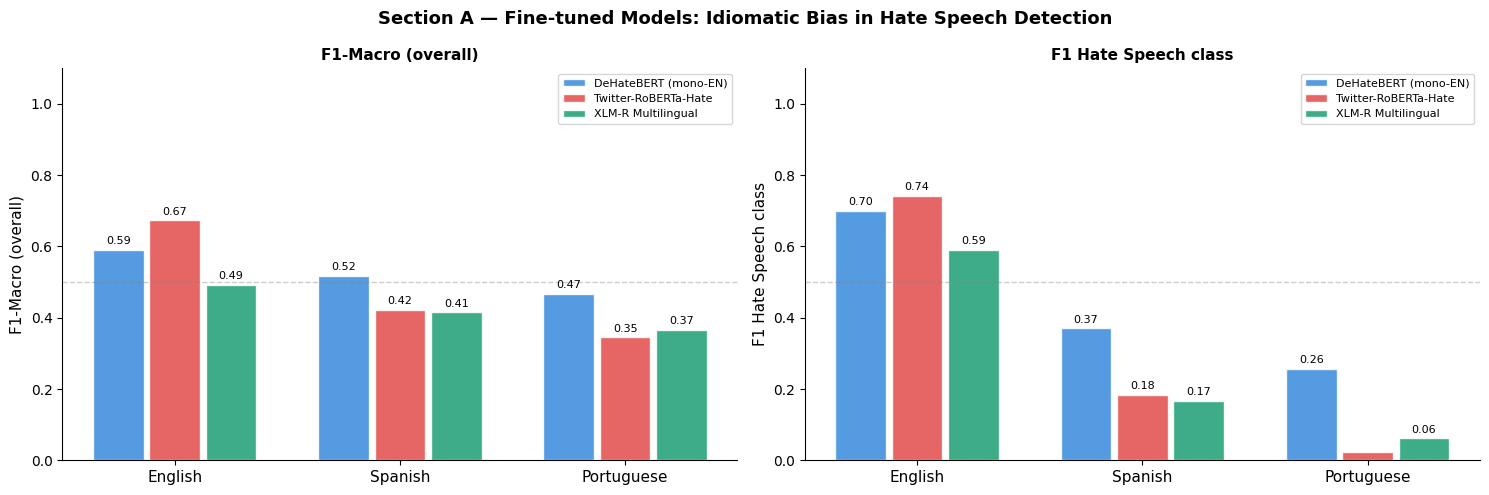

In [ ]:
# ── Section A visualization ─────────────────────────────────────────────────
models_a  = list(results_ft.keys())
langs     = ['en', 'es', 'pt']
palette_a = ['#378ADD', '#E24B4A', '#1D9E75']
x = np.arange(3)
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Section A — Fine-tuned Models: Idiomatic Bias in Hate Speech Detection',
             fontsize=13, fontweight='bold')

for ax, metric, title in zip(axes,
    ['f1_macro', 'f1_hate'],
    ['F1-Macro (overall)', 'F1 Hate Speech class']):

    for i, (model, color) in enumerate(zip(models_a, palette_a)):
        vals = [results_ft[model][l][metric] if l in results_ft[model] else 0 for l in langs]
        offset = (i - 1) * w
        bars = ax.bar(x + offset, vals, w * 0.9,
                      label=model, color=color, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 0.05:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(['English', 'Spanish', 'Portuguese'], fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.legend(fontsize=8, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(title, fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('section_a_results.png', dpi=150, bbox_inches='tight')
plt.show()

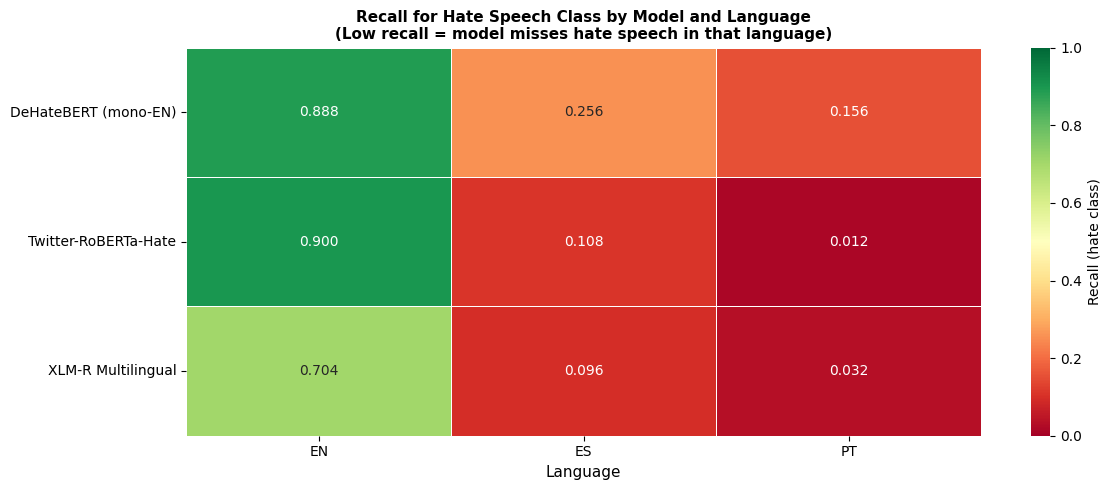

In [ ]:
# ── Recall analysis: the key evidence of idiomatic bias ────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

recall_data = []
for model in models_a:
    for lang in langs:
        if lang in results_ft[model]:
            recall_data.append({
                'Model': model,
                'Language': lang.upper(),
                'Recall': results_ft[model][lang]['recall'],
                'Precision': results_ft[model][lang]['precision']
            })

df_recall = pd.DataFrame(recall_data)
pivot_r = df_recall.pivot(index='Model', columns='Language', values='Recall')

sns.heatmap(pivot_r, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Recall (hate class)'})
ax.set_title('Recall for Hate Speech Class by Model and Language\n'
             '(Low recall = model misses hate speech in that language)',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Language', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section B — LLMs via Prompting (LLaMA-3.1-8B via Groq)

Unlike fine-tuned models, LLMs receive explicit instructions in natural language. We test whether prompting **in the language of the text** improves detection in ES and PT.

**Strategies evaluated:**
- **Zero-shot**: instruction + text, no examples
- **Few-shot**: instruction + 6 labeled examples + text

> **Key question**: Does reasoning in the language of the text close the idiomatic gap that fine-tuned models cannot bridge?

In [ ]:
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)

SYSTEM_PROMPTS = {
    'en': """You are a hate speech detection classifier. Your task is to determine whether a given tweet contains hate speech.
Hate speech is defined as language that attacks or demeans a person or group based on attributes such as race, ethnicity, religion, gender, sexual orientation, or immigration status.
Important: Consider implicit hate speech including metaphors, irony, sarcasm, and euphemisms — these often disguise hateful intent.
Respond with ONLY the word HATE or NOT_HATE, nothing else.""",

    'es': """Eres un clasificador de discurso de odio. Tu tarea es determinar si un tweet dado contiene discurso de odio.
El discurso de odio se define como el lenguaje que ataca o denigra a una persona o grupo por atributos como raza, etnia, religión, género, orientación sexual o situación migratoria.
Importante: Considera el discurso de odio implícito que incluye metáforas, ironías, sarcasmos y eufemismos — a menudo disfrazan la intención de odio.
Responde ÚNICAMENTE con la palabra ODIO o NO_ODIO, sin nada más.""",

    'pt': """Você é um classificador de discurso de ódio. Sua tarefa é determinar se um dado tweet contém discurso de ódio.
O discurso de ódio é definido como linguagem que ataca ou denigre uma pessoa ou grupo com base em atributos como raça, etnia, religião, gênero, orientação sexual ou status migratório.
Importante: Considere o discurso de ódio implícito incluindo metáforas, ironia, sarcasmo e eufemismos — estes frequentemente disfarçam a intenção de ódio.
Responda APENAS com a palavra ÓDIO ou NÃO_ÓDIO, sem mais nada."""
}

FEW_SHOT_EXAMPLES = {
    'en': [
        ("All immigrants are criminals who steal jobs.", "HATE"),
        ("We should 'clean up' our country of people who don't belong.", "HATE"),
        ("Those people are like a plague spreading everywhere.", "HATE"),
        ("I disagree with immigration policy but respect all people.", "NOT_HATE"),
        ("The football match last night was incredible!", "NOT_HATE"),
        ("I'm proud of my cultural heritage.", "NOT_HATE"),
    ],
    'es': [
        ("Todos los inmigrantes son criminales que roban empleos.", "ODIO"),
        ("Deberíamos limpiar el país de gente que no pertenece aquí.", "ODIO"),
        ("Esa gente es como una plaga que se expande por todas partes.", "ODIO"),
        ("Estoy en desacuerdo con la política migratoria pero respeto a todas las personas.", "NO_ODIO"),
        ("El partido de fútbol anoche fue increíble.", "NO_ODIO"),
        ("Estoy orgulloso de mi herencia cultural.", "NO_ODIO"),
    ],
    'pt': [
        ("Todos os imigrantes são criminosos que roubam empregos.", "ÓDIO"),
        ("Deveríamos fazer uma limpeza no país e tirar quem não pertence.", "ÓDIO"),
        ("Esse povo é como uma praga que se espalha por todo lugar.", "ÓDIO"),
        ("Discordo da política migratória mas respeito todas as pessoas.", "NÃO_ÓDIO"),
        ("O jogo de futebol ontem à noite foi incrível.", "NÃO_ÓDIO"),
        ("Tenho orgulho da minha herança cultural.", "NÃO_ÓDIO"),
    ]
}

HATE_LABELS = {
    'en': {'HATE', 'HATE.'},
    'es': {'ODIO', 'ODIO.'},
    'pt': {'ÓDIO', 'ÓDIO.', 'ODIO', 'ODIO.'}
}

print(' Prompts configured for EN, ES, PT')

 Prompts configured for EN, ES, PT


In [ ]:
def classify_with_groq(text, lang, strategy='zero-shot',
                        model='llama-3.1-8b-instant', max_retries=3, delay=1.0):
    system_prompt = SYSTEM_PROMPTS[lang]
    if strategy == 'few-shot':
        examples = FEW_SHOT_EXAMPLES[lang]
        examples_txt = "\n".join([f"Text: {t}\nClassification: {l}" for t, l in examples])
        if lang == 'en':
            user_content = f"Examples:\n{examples_txt}\n\nNow classify:\nText: {text}\nClassification:"
        elif lang == 'es':
            user_content = f"Ejemplos:\n{examples_txt}\n\nAhora clasifica:\nTexto: {text}\nClasificación:"
        else:
            user_content = f"Exemplos:\n{examples_txt}\n\nAgora classifique:\nTexto: {text}\nClassificação:"
    else:
        prefix = 'Text' if lang == 'en' else 'Texto'
        user_content = f"{prefix}: {text}"

    # Etiquetas exactas de NO-hate por idioma
    NO_HATE_LABELS = {
        'en': {'NOT_HATE', 'NOT_HATE.', 'NOT HATE'},
        'es': {'NO_ODIO', 'NO_ODIO.', 'NO ODIO'},
        'pt': {'NÃO_ÓDIO', 'NÃO_ÓDIO.', 'NÃO ÓDIO', 'NAO_ODIO', 'NAO ODIO'}
    }

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_content}
                ],
                max_tokens=10,
                temperature=0.0
            )
            answer = response.choices[0].message.content.strip().upper()

            # Primero chequear no-hate explícitamente
            if any(nh in answer for nh in NO_HATE_LABELS[lang]):
                return 0
            # Luego chequear hate
            if any(hl in answer for hl in HATE_LABELS[lang]):
                return 1
            # Si no matchea ninguno, default conservador = no hate
            print(f"  ⚠️  Respuesta no reconocida [{lang}]: '{answer}' → asignando 0")
            return 0

        except Exception:
            if attempt < max_retries - 1:
                time.sleep(delay * (attempt + 1))
            else:
                return 0


def evaluate_llm_groq(samples_dict, strategy='zero-shot', n_samples=100,
                       model='llama-3.1-8b-instant', delay=0.3):
    print(f"\n Evaluating LLaMA-3.1-8B ({strategy}) — {n_samples} examples per language")
    results = {}
    for lang, df in samples_dict.items():
        subset = df.sample(min(n_samples, len(df)), random_state=SEED)
        y_true, y_pred = [], []
        for _, row in tqdm(subset.iterrows(), total=len(subset),
                           desc=f"  [{lang.upper()}]"):
            pred = classify_with_groq(row['text'], lang, strategy=strategy, model=model)
            y_true.append(row['HS'])
            y_pred.append(pred)
            time.sleep(delay)

        f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
        f1_hate  = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        prec     = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        rec      = recall_score(y_true, y_pred, pos_label=1, zero_division=0)

        results[lang] = {
            'f1_macro':  round(f1_macro, 4),
            'f1_hate':   round(f1_hate, 4),
            'precision': round(prec, 4),
            'recall':    round(rec, 4),
            'y_true':    y_true,
            'y_pred':    y_pred
        }
        print(f"  [{lang.upper()}] F1-macro: {f1_macro:.3f} | F1-hate: {f1_hate:.3f} | P: {prec:.3f} | R: {rec:.3f}")
    return results

print('LLM evaluation functions ready')

LLM evaluation functions ready


In [ ]:
# ── Quick connectivity test ─────────────────────────────────────────────────
print(" Testing Groq API connection...")
test_cases = [
    ("I hate all immigrants, they should go back.", 'en', 1),
    ("The weather is nice today.", 'en', 0),
    ("Todos los inmigrantes son una plaga para este país.", 'es', 1),
    ("Esses imigrantes roubam nossos empregos.", 'pt', 1),
    ("Estou feliz com minha família hoje.", 'pt', 0),
]

for text, lang, expected in test_cases:
    pred = classify_with_groq(text, lang, strategy='zero-shot')
    status = '✅' if pred == expected else '❌'
    print(f"  {status} [{lang.upper()}] Pred={pred} | Expected={expected} | '{text[:55]}...'")

print("\n If most show ✅, the API is working correctly.")

 Testing Groq API connection...
  ✅ [EN] Pred=1 | Expected=1 | 'I hate all immigrants, they should go back....'
  ✅ [EN] Pred=0 | Expected=0 | 'The weather is nice today....'
  ✅ [ES] Pred=1 | Expected=1 | 'Todos los inmigrantes son una plaga para este país....'
  ✅ [PT] Pred=1 | Expected=1 | 'Esses imigrantes roubam nossos empregos....'
  ✅ [PT] Pred=0 | Expected=0 | 'Estou feliz com minha família hoje....'

 If most show ✅, the API is working correctly.


In [ ]:
# ── Zero-shot evaluation ────────────────────────────────────────────────────
# Start with N_EVAL=100. Change to 250 for the full experiment.
N_EVAL = 100

results_llm_zero = evaluate_llm_groq(
    samples, strategy='zero-shot', n_samples=N_EVAL, delay=0.3
)


 Evaluating LLaMA-3.1-8B (zero-shot) — 100 examples per language


  [EN]: 100%|██████████| 100/100 [03:14<00:00,  1.94s/it]


  [EN] F1-macro: 0.487 | F1-hate: 0.636 | P: 0.477 | R: 0.953


  [ES]: 100%|██████████| 100/100 [04:14<00:00,  2.55s/it]


  [ES] F1-macro: 0.662 | F1-hate: 0.612 | P: 0.619 | R: 0.605


  [PT]: 100%|██████████| 100/100 [04:14<00:00,  2.55s/it]

  [PT] F1-macro: 0.627 | F1-hate: 0.475 | P: 0.875 | R: 0.326


In [ ]:
# ── Few-shot evaluation ─────────────────────────────────────────────────────
results_llm_few = evaluate_llm_groq(
    samples, strategy='few-shot', n_samples=N_EVAL, delay=0.3
)


 Evaluating LLaMA-3.1-8B (few-shot) — 100 examples per language


  [EN]:  26%|██▌       | 26/100 [00:14<00:35,  2.09it/s]

  ⚠️  Respuesta no reconocida [en]: 'I CANNOT CREATE EXPLICIT CONTENT. CAN I HELP YOU' → asignando 0


  [EN]: 100%|██████████| 100/100 [03:38<00:00,  2.18s/it]


  [EN] F1-macro: 0.403 | F1-hate: 0.618 | P: 0.452 | R: 0.977


  [ES]: 100%|██████████| 100/100 [06:12<00:00,  3.73s/it]


  [ES] F1-macro: 0.649 | F1-hate: 0.712 | P: 0.560 | R: 0.977


  [PT]: 100%|██████████| 100/100 [06:32<00:00,  3.93s/it]

  [PT] F1-macro: 0.779 | F1-hate: 0.766 | P: 0.706 | R: 0.837


---
## 5. Comparative Analysis and Visualization

In [ ]:
# ── Compile all results ─────────────────────────────────────────────────────
all_results = []

for model, res_dict in results_ft.items():
    for lang, metrics in res_dict.items():
        all_results.append({
            'model': model, 'type': 'Fine-tuned',
            'language': lang.upper(),
            'f1_macro':  metrics['f1_macro'],
            'f1_hate':   metrics['f1_hate'],
            'precision': metrics['precision'],
            'recall':    metrics['recall']
        })

for lang, metrics in results_llm_zero.items():
    all_results.append({
        'model': 'LLaMA-3.1-8B (zero-shot)', 'type': 'LLM Prompting',
        'language': lang.upper(),
        'f1_macro':  metrics['f1_macro'],
        'f1_hate':   metrics['f1_hate'],
        'precision': metrics['precision'],
        'recall':    metrics['recall']
    })

for lang, metrics in results_llm_few.items():
    all_results.append({
        'model': 'LLaMA-3.1-8B (few-shot)', 'type': 'LLM Prompting',
        'language': lang.upper(),
        'f1_macro':  metrics['f1_macro'],
        'f1_hate':   metrics['f1_hate'],
        'precision': metrics['precision'],
        'recall':    metrics['recall']
    })

df_results = pd.DataFrame(all_results)
print("Full results table:")
print(df_results.to_string(index=False))

Full results table:
                   model          type language  f1_macro  f1_hate  precision  recall
    DeHateBERT (mono-EN)    Fine-tuned       EN    0.5906   0.7003     0.5781  0.8880
    DeHateBERT (mono-EN)    Fine-tuned       ES    0.5183   0.3699     0.6667  0.2560
    DeHateBERT (mono-EN)    Fine-tuned       PT    0.4673   0.2574     0.7358  0.1560
    Twitter-RoBERTa-Hate    Fine-tuned       EN    0.6733   0.7426     0.6320  0.9000
    Twitter-RoBERTa-Hate    Fine-tuned       ES    0.4219   0.1837     0.6136  0.1080
    Twitter-RoBERTa-Hate    Fine-tuned       PT    0.3456   0.0236     0.7500  0.0120
      XLM-R Multilingual    Fine-tuned       EN    0.4933   0.5906     0.5087  0.7040
      XLM-R Multilingual    Fine-tuned       ES    0.4148   0.1667     0.6316  0.0960
      XLM-R Multilingual    Fine-tuned       PT    0.3669   0.0618     0.8889  0.0320
LLaMA-3.1-8B (zero-shot) LLM Prompting       EN    0.4868   0.6357     0.4767  0.9535
LLaMA-3.1-8B (zero-shot) LLM Promp

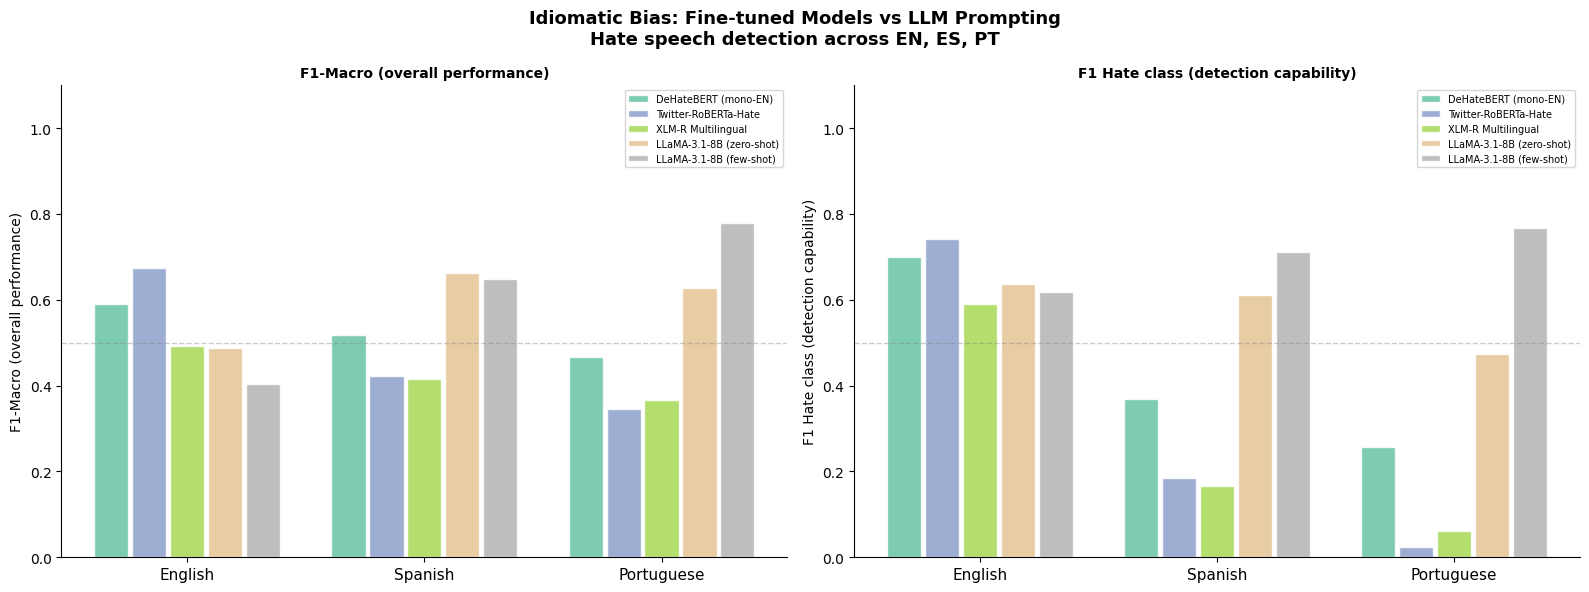

In [ ]:
# ── Main comparison chart: Fine-tuned vs LLM ───────────────────────────────
all_models = df_results['model'].unique()
palette_all = plt.cm.Set2(np.linspace(0, 1, len(all_models)))
x = np.arange(3)
w = 0.8 / len(all_models)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Idiomatic Bias: Fine-tuned Models vs LLM Prompting\n'
             'Hate speech detection across EN, ES, PT',
             fontsize=13, fontweight='bold')

for ax, metric, title in zip(axes,
    ['f1_macro', 'f1_hate'],
    ['F1-Macro (overall performance)', 'F1 Hate class (detection capability)']):

    for i, (model, color) in enumerate(zip(all_models, palette_all)):
        vals = []
        for lang in ['EN', 'ES', 'PT']:
            row = df_results[(df_results['model'] == model) &
                             (df_results['language'] == lang)]
            vals.append(row[metric].values[0] if len(row) else 0)
        offset = (i - (len(all_models)-1)/2) * w
        ax.bar(x + offset, vals, w * 0.9,
               label=model, color=color, alpha=0.85, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(['English', 'Spanish', 'Portuguese'], fontsize=11)
    ax.set_ylabel(title, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.legend(fontsize=7, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(title, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

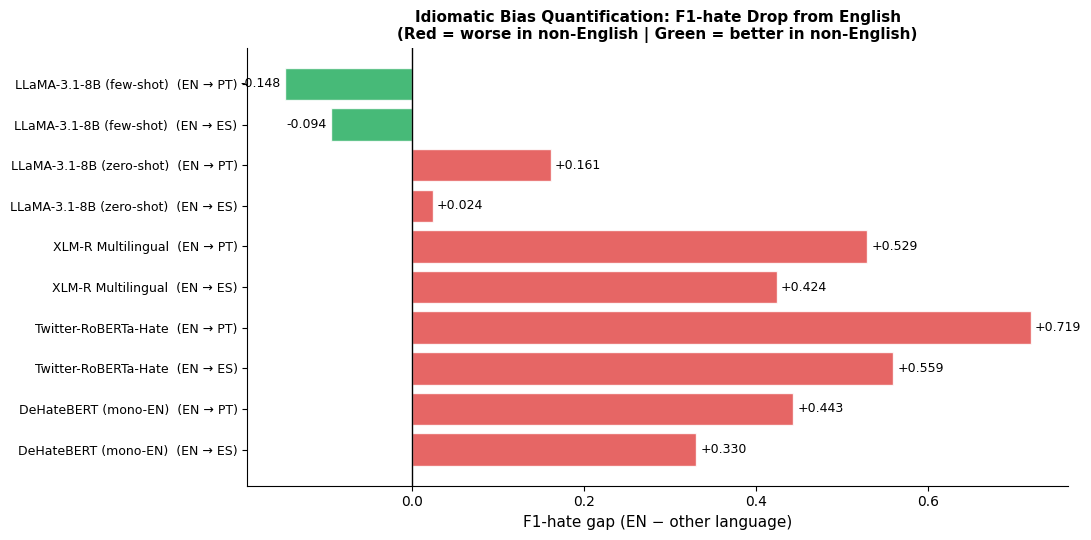

In [ ]:
# ── Idiomatic gap quantification ────────────────────────────────────────────
gaps = []
for model in all_models:
    data = df_results[df_results['model'] == model]
    f1_en = data[data['language'] == 'EN']['f1_hate'].values
    f1_es = data[data['language'] == 'ES']['f1_hate'].values
    f1_pt = data[data['language'] == 'PT']['f1_hate'].values
    if len(f1_en) and len(f1_es):
        gaps.append({'model': model, 'comparison': 'EN → ES',
                     'gap': round(float(f1_en[0] - f1_es[0]), 4)})
    if len(f1_en) and len(f1_pt):
        gaps.append({'model': model, 'comparison': 'EN → PT',
                     'gap': round(float(f1_en[0] - f1_pt[0]), 4)})

df_gaps = pd.DataFrame(gaps)

fig, ax = plt.subplots(figsize=(11, max(5, len(df_gaps) * 0.55)))
colors = ['#E24B4A' if g > 0 else '#27AE60' for g in df_gaps['gap']]
bars = ax.barh(range(len(df_gaps)), df_gaps['gap'],
               color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(df_gaps)))
ax.set_yticklabels(
    [f"{r['model']}  ({r['comparison']})" for _, r in df_gaps.iterrows()],
    fontsize=9)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('F1-hate gap (EN − other language)', fontsize=11)
ax.set_title('Idiomatic Bias Quantification: F1-hate Drop from English\n'
             '(Red = worse in non-English | Green = better in non-English)',
             fontweight='bold', fontsize=11)
for bar, val in zip(bars, df_gaps['gap']):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('idiomatic_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

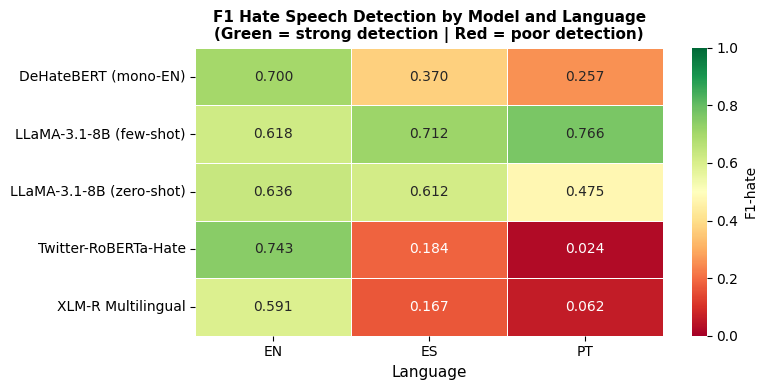

In [ ]:
# ── F1-hate heatmap: all models × languages ─────────────────────────────────
pivot = df_results.pivot_table(index='model', columns='language', values='f1_hate')

fig, ax = plt.subplots(figsize=(8, max(4, len(pivot) * 0.7)))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'F1-hate'})
ax.set_title('F1 Hate Speech Detection by Model and Language\n'
             '(Green = strong detection | Red = poor detection)',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Language', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('f1hate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Executive summary ───────────────────────────────────────────────────────
print('=' * 68)
print('EXECUTIVE SUMMARY — IDIOMATIC BIAS IN HATE SPEECH DETECTION')
print('=' * 68)

for model in all_models:
    data = df_results[df_results['model'] == model]
    print(f'\n  {model}')
    for lang in ['EN', 'ES', 'PT']:
        row = data[data['language'] == lang]
        if len(row):
            r = row.iloc[0]
            print(f'    {lang}: F1-macro={r["f1_macro"]:.3f} | F1-hate={r["f1_hate"]:.3f} | P={r["precision"]:.3f} | R={r["recall"]:.3f}')

print('\n' + '=' * 68)
print('IDIOMATIC GAPS (F1-hate EN − other language):')
print('=' * 68)
print(df_gaps.to_string(index=False))
if len(df_gaps):
    avg_en_es = df_gaps[df_gaps['comparison']=='EN → ES']['gap'].mean()
    avg_en_pt = df_gaps[df_gaps['comparison']=='EN → PT']['gap'].mean()
    print(f'\nAverage gap EN → ES: {avg_en_es:+.3f}')
    print(f'Average gap EN → PT: {avg_en_pt:+.3f}')

EXECUTIVE SUMMARY — IDIOMATIC BIAS IN HATE SPEECH DETECTION

  DeHateBERT (mono-EN)
    EN: F1-macro=0.591 | F1-hate=0.700 | P=0.578 | R=0.888
    ES: F1-macro=0.518 | F1-hate=0.370 | P=0.667 | R=0.256
    PT: F1-macro=0.467 | F1-hate=0.257 | P=0.736 | R=0.156

  Twitter-RoBERTa-Hate
    EN: F1-macro=0.673 | F1-hate=0.743 | P=0.632 | R=0.900
    ES: F1-macro=0.422 | F1-hate=0.184 | P=0.614 | R=0.108
    PT: F1-macro=0.346 | F1-hate=0.024 | P=0.750 | R=0.012

  XLM-R Multilingual
    EN: F1-macro=0.493 | F1-hate=0.591 | P=0.509 | R=0.704
    ES: F1-macro=0.415 | F1-hate=0.167 | P=0.632 | R=0.096
    PT: F1-macro=0.367 | F1-hate=0.062 | P=0.889 | R=0.032

  LLaMA-3.1-8B (zero-shot)
    EN: F1-macro=0.487 | F1-hate=0.636 | P=0.477 | R=0.954
    ES: F1-macro=0.662 | F1-hate=0.612 | P=0.619 | R=0.605
    PT: F1-macro=0.627 | F1-hate=0.475 | P=0.875 | R=0.326

  LLaMA-3.1-8B (few-shot)
    EN: F1-macro=0.403 | F1-hate=0.618 | P=0.452 | R=0.977
    ES: F1-macro=0.649 | F1-hate=0.712 | P=0.560

In [ ]:
# ── Export all results ──────────────────────────────────────────────────────
df_results.to_csv('experiment_results_complete.csv', index=False)
df_gaps.to_csv('idiomatic_gaps.csv', index=False)

print('✅ Results exported:')
print('   - experiment_results_complete.csv')
print('   - idiomatic_gaps.csv')
print('   - dataset_distribution.png')
print('   - section_a_results.png')
print('   - recall_heatmap.png')
print('   - full_comparison.png')
print('   - idiomatic_gaps.png')
print('   - f1hate_heatmap.png')
